In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.model_selection import train_test_split
import csv

Setting device on gpu

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cpu')

Loading Dataset

In [4]:
data = pd.read_csv('fashion-mnist_train.csv')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [6]:
data.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


In [7]:
data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


Extracting features and labels


In [9]:
x= data.iloc[:,1:].values

In [10]:
y= data.iloc[:,0].values

In [11]:
y

array([2, 9, 6, ..., 8, 8, 7])

In [12]:
y.shape

(60000,)

Making test and train sets

In [13]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2)

Normalizing the values of pixels

In [14]:
x_train= x_train/255.0
x_test= x_test/255.0

In [15]:
type(x_train)

numpy.ndarray

Creating the Model Architecture

In [16]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.hidden1 = nn.Linear(num_features,16)

    self.leftHidden1 = nn.Linear(16,8)

    self.leftHidden2 = nn.Linear(8,8)


    self.rightHidden1 = nn.Linear(16,12)

    self.rightHidden2 = nn.Linear(12,8)

    self.finalHidden = nn.Linear(16,10)

    self.relu = nn.ReLU()

  def forward(self,x):
    hiddenOut = self.hidden1(x)
    hiddenReLU = self.relu(hiddenOut)

    #Separating into left side of the parallel Neural Network
    leftOut1 = self.leftHidden1(hiddenReLU)
    leftReLU1= self.relu(leftOut1)

    leftOut2 = self.leftHidden2(leftReLU1)
    leftReLU2= self.relu(leftOut2)

    #That skipping part (Searched and found it is for the minimising of the losses of features due to many hidden layers )
    leftSkip = leftReLU1 + leftReLU2

    #Separating into right side of the parallel Neural Network
    rightOut1= self.rightHidden1(hiddenReLU)
    rightReLU1= self.relu(rightOut1)

    rightOut2= self.rightHidden2(rightReLU1)
    rightReLU2= self.relu(rightOut2)

    #Joining the networks
    concatOut = torch.cat((leftReLU2, rightReLU2),dim=1)

    finalOut = self.finalHidden(concatOut)


    return finalOut

Setting epochs and learning rate

In [20]:
epochs= 100
lr= 0.1

x_train.shape

(48000, 784)

Initializing the model and key components

In [21]:
model = MyNN(784)
model= model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4)

Training the model on the training dataset

In [22]:
# To display the training and testing dataset loss and accuracy graphs
training_accuracy = []
training_loss = []
testing_accuracy = []
testing_loss = []

for epoch in range(epochs):
    # training model
    model.train()
    train_loss = 0
    train_total = 0
    train_correct = 0

    for num in range(0, x_train.shape[0], 32):
        x_tensor = torch.tensor(x_train[num:num+32, :], dtype=torch.float32).to(device)
        y_tensor = torch.tensor(y_train[num:num+32], dtype=torch.long).to(device)

        outputs = model.forward(x_tensor)
        loss = criterion(outputs, y_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_tensor.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += y_tensor.size(0)
        train_correct += (predicted == y_tensor).sum().item()

    # Appending the loss and accuracy after one epoch
    training_loss.append(train_loss / x_train.shape[0])
    training_accuracy.append(train_correct / train_total)

    # Testing the model
    model.eval()
    test_loss = 0
    test_total = 0
    test_correct = 0

    with torch.no_grad():
        for num in range(0, x_test.shape[0], 32):
            x_tensor = torch.tensor(x_test[num:num+32, :], dtype=torch.float32).to(device)
            y_tensor = torch.tensor(y_test[num:num+32], dtype=torch.long).to(device)

            outputs = model(x_tensor)

            loss = criterion(outputs, y_tensor)

            test_loss += loss.item() * x_tensor.size(0)
            _, predicted = torch.max(outputs, 1)
            test_total += y_tensor.size(0)
            test_correct += (predicted == y_tensor).sum().item()

    # Appending the loss and accuracy after one epoch
    testing_loss.append(test_loss / x_test.shape[0])
    testing_accuracy.append(test_correct / test_total)


    print(epoch,
          f"Train Loss: {training_loss[-1]}, Train Acc: {training_accuracy[-1]*100}%  ",
          f"Test Loss: {testing_loss[-1]:.4f}, Test Acc: {testing_accuracy[-1]*100:}%")

0 Train Loss: 0.760693723966678, Train Acc: 71.4125%   Test Loss: 0.5087, Test Acc: 81.45%
1 Train Loss: 0.4944033650457859, Train Acc: 81.95833333333333%   Test Loss: 0.4652, Test Acc: 83.65833333333333%
2 Train Loss: 0.4498040733188391, Train Acc: 83.53541666666666%   Test Loss: 0.4600, Test Acc: 83.74166666666667%
3 Train Loss: 0.42360306773086387, Train Acc: 84.5375%   Test Loss: 0.4379, Test Acc: 84.41666666666666%
4 Train Loss: 0.40660180568446713, Train Acc: 85.09583333333333%   Test Loss: 0.4266, Test Acc: 84.89999999999999%
5 Train Loss: 0.39370363418509563, Train Acc: 85.57916666666667%   Test Loss: 0.4226, Test Acc: 85.10833333333333%
6 Train Loss: 0.38299988905588783, Train Acc: 86.01666666666667%   Test Loss: 0.4057, Test Acc: 85.55%
7 Train Loss: 0.3755051715970039, Train Acc: 86.25833333333334%   Test Loss: 0.4161, Test Acc: 85.075%
8 Train Loss: 0.36800415254135926, Train Acc: 86.59375%   Test Loss: 0.4117, Test Acc: 85.38333333333334%
9 Train Loss: 0.3623493568499883, 

Plotting Loss vs Epoch for Train and Test Datasets

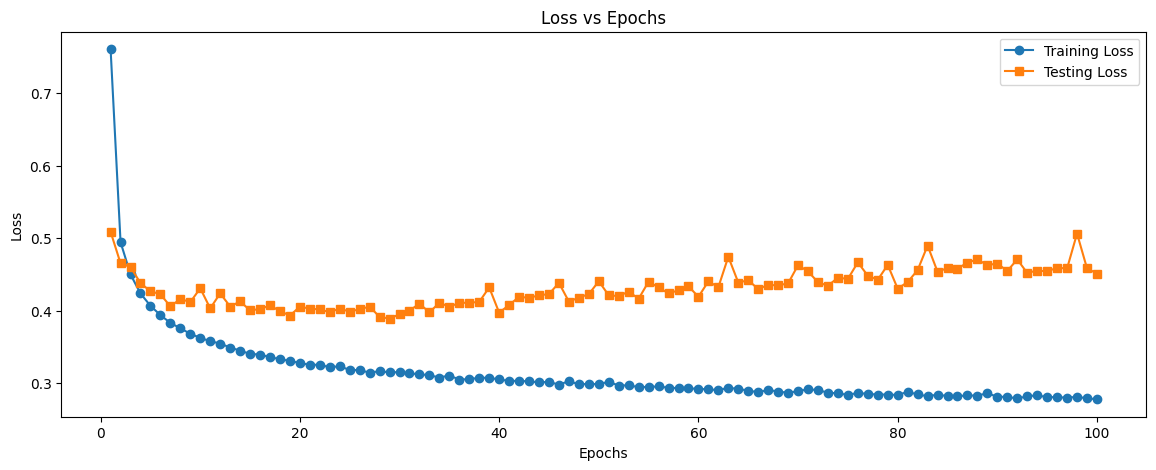

In [23]:
fig, axes = plt.subplots(1, figsize=(14, 5))

# Loss Plot
axes.plot(range(1, epochs + 1), training_loss, label='Training Loss', marker='o')
axes.plot(range(1, epochs + 1), testing_loss, label='Testing Loss', marker='s')
axes.set_title('Loss vs Epochs')
axes.set_xlabel('Epochs')
axes.set_ylabel('Loss')
axes.legend()





plt.savefig('loss_train_test.png')
plt.show()

The image suggests that beyond 50 there is minimal loss change and hence to reduce computations, epochs=50 would be optimal in this case. Beyond that the loss difference between test and train datasets has also started to increase

Plotting Accuracy vs Epoch for Train and Test Datasets

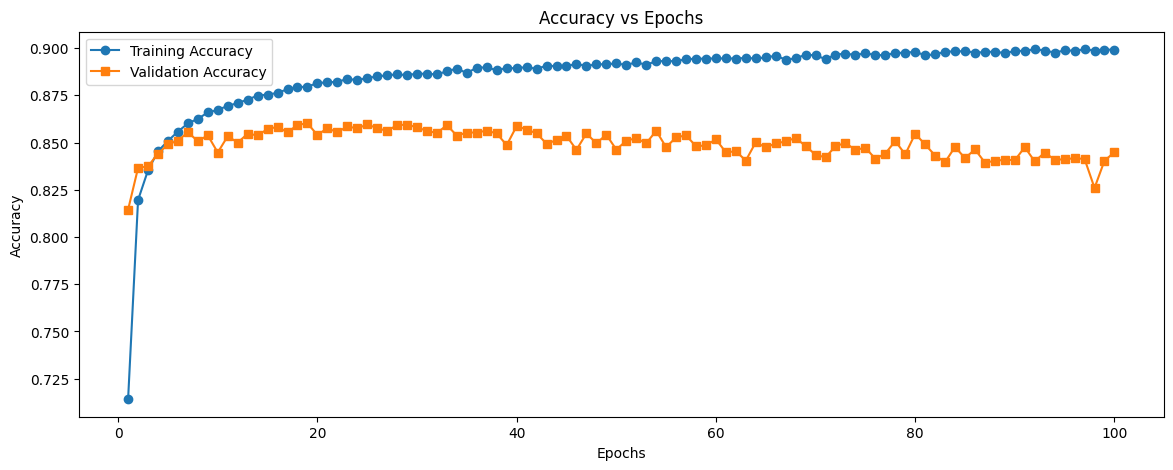

In [24]:
fig, axes = plt.subplots(1, figsize=(14, 5))
# Accuracy Plot
axes.plot(range(1, epochs + 1),training_accuracy, label='Training Accuracy', marker='o')
axes.plot(range(1, epochs + 1), testing_accuracy, label='Validation Accuracy', marker='s')
axes.set_title('Accuracy vs Epochs')
axes.set_xlabel('Epochs')
axes.set_ylabel('Accuracy')
axes.legend()



plt.savefig('accuracy_train_test.png')
plt.show()

The same goes for accuracy, epochs =50 seems to be an optimal number. Beyond that the accuracy difference between test and train datasets has also started to increase

Now saving the required files as per requirements in the task


In [25]:
#SAving weights
weights_file = 'model_weights.pkl'
with open(weights_file, 'wb') as f:
    pickle.dump(model.state_dict(), f)



model.eval()
predictions = []


#Saving submission file

with torch.no_grad():
    for num in range(0, x_test.shape[0], 32):
        x_tensor = torch.tensor(x_test[num:num+32, :], dtype=torch.float32).to(device)
        outputs = model(x_tensor)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy())

csv_filename = 'submission.csv'

with open(csv_filename, mode='w', newline='') as csv_file:
    writer = csv.writer(csv_file)


    writer.writerow(['Id', 'Label'])


    for idx, label in enumerate(predictions):

        writer.writerow([idx + 1, label])


